# Modeling

Here we are trying to train a model that would successfully detect fraudulent transactions. Of course, the ideal result is to get a model that makes no mistake and correctly flag every fraudulent transaction it sees, but no model is perfect and it comes with some trade-offs to consider. 

For this particular task of fraud detection, i decided to train and compare 3 different models : 
- A logistic regression model, which is a very simple and interpretable model, to verify if the fraud patterns are mostly linear. Even if it doesn't work properly, it makes a good baseline to understand what works and what doesn't on this particular task.
- A random forest model, which is a model of medium complexity and interpretability. As we discovered multiple predictive ideas for fraud, like night transactions, high amount of money and type of transactions, these might interact and a random forest can model those interactions efficiently with decision trees. It also is robust to outliers, and requires almost no feature engineering, making it quite suitable for the task.
- Finally, the XGBoost model. The more complex and less interpretable between those 3, it might be the most powerful one. It is still based on decision trees, but here builds trees sequentially, and each tree learns from the mistakes of the previous one.

In [1]:
from pathlib import Path
import pandas as pd

banking_df = pd.read_csv("../data/processed/modeling_df.csv")

In [2]:
banking_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 8 columns):
 #   Column          Dtype  
---  ------          -----  
 0   Unnamed: 0      int64  
 1   type            object 
 2   amount          float64
 3   oldbalanceOrg   float64
 4   oldbalanceDest  float64
 5   newbalanceOrig  float64
 6   newbalanceDest  float64
 7   isFraud         int64  
dtypes: float64(5), int64(2), object(1)
memory usage: 388.3+ MB


## 1. Splitting and Sampling

First step in creating our model is to sample our dataset and creating our train/test/validation sets. The idea is that splitting should create subsets as representative as possible of the original data in our test and validation set, to provide realistic evaluation of our model(s). 

Since we've previously shown huge data imbalance as well as some patterns we want our model to learn on, we'll use a stratified split method to maximize data representativity. 
Stratify our splits is a method used to prevent variables to be badly represented in the splitted sets by some random splitting. This is particularly critical with little datasets, but here it just serves as a good practice. 

I want to split and create my subsets here before down-sampling the train set, because i don't want to change unadvertedly the distribution of variables from validation and test set. Down-sampling the train set might be useful to accelerate my model's training, which may be long otherwise. 

In [3]:
from sklearn.model_selection import train_test_split

df = banking_df.copy()

train_df, test_df = train_test_split(
    df,
    test_size=0.20,
    stratify=df["isFraud"],
    random_state=42
)

print("Train:", train_df.shape)
print("Test:", test_df.shape)

Train: (5090096, 8)
Test: (1272524, 8)


In [4]:
for name, subset in {
    "Train": train_df,
    "Test": test_df,
    "Original": banking_df
}.items():
    fraud_rate = subset["isFraud"].mean() * 100
    print(f"{name}: {fraud_rate:.4f}% fraud")

Train: 0.1291% fraud
Test: 0.1291% fraud
Original: 0.1291% fraud


In [5]:
drop_cols = ["isFraud"]

X_train = train_df.drop(columns="isFraud")
y_train = train_df["isFraud"]

X_test = test_df.drop(columns="isFraud")
y_test = test_df["isFraud"]

## 2. Preprocessing data

Alright. Now that we have our subsets, my goal is to preprocess data in order for my models to learn correctly.
I want to explore 3 different models : A simple logistic regression model, A random forest model and a XGBoost model. 
Some of them, like the random forest model doesn't need extensive preprocessing for the data, but it still remains a vital step. 

In [6]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import OneHotEncoder

num_attribs = ["amount", "oldbalanceOrg", "newbalanceOrig", "oldbalanceDest", "newbalanceDest"]
cat_attribs = ["type"]

num_pipeline = Pipeline([
    ("scalar", MinMaxScaler())])

cat_pipeline = Pipeline([
    ("OH_encoding", OneHotEncoder(handle_unknown="ignore"))])

preprocessing = ColumnTransformer([
    ("num", num_pipeline, num_attribs),
    ("cat", cat_pipeline, cat_attribs)])



In [7]:
X_train_prepared = preprocessing.fit_transform(X_train)
X_test_prepared = preprocessing.transform(X_test)

## 3. Training Models

Now, we can actually try to select and train some models. 
3 of them might be relevant : 
- Logistic Regression Model
- Random Forest Model
- XGBoost Model

## 3.1 Select models

To actually select promising models we need to train them and evaluate them in reliable way. 
K-fold cross validation is an excellent way of doing so. Before using it though, it is mandatory to downsample the train set again, 
because we could end up training too many models on way too much data. The downsampling should be stratified at least using our target, to make sure the fraud rate is at least the same on each created subsets during the process. A better downsampling could also be done using combined stratification (using target and other variables, or even engineered variables, if needed). 

In [8]:
X_train_reduced_5, _, y_train_reduced_5, _ = train_test_split(
    X_train_prepared,
    y_train,
    train_size=0.05,      # Downsampling to 5%
    stratify=y_train,
    random_state=42
)

In [9]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(
    max_iter=100,
    class_weight="balanced", #To prevent class imbalance issues, or the model will just always predict the major class. 
    random_state=42
)

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = cross_val_score(
    log_model,
    X_train_reduced_5,
    y_train_reduced_5,
    cv=cv,
    scoring="f1",
    n_jobs=-1
)

print(scores)
print(f"Mean F1 : {scores.mean():.4f}")
print(f"Std  F1 : {scores.std():.4f}")

[0.02057019 0.01961524 0.01604542 0.02041488 0.0201005 ]
Mean F1 : 0.0193
Std  F1 : 0.0017


In [10]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = cross_val_score(
    rf_model,
    X_train_reduced_5,
    y_train_reduced_5,
    cv=cv,
    scoring="f1",
    n_jobs=-1
)

print(scores)
print(f"Mean F1 : {scores.mean():.4f}")
print(f"Std  F1 : {scores.std():.4f}")

[0.85217391 0.79279279 0.85470085 0.88333333 0.84482759]
Mean F1 : 0.8456
Std  F1 : 0.0295


In [11]:
import xgboost as xgb

xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    random_state=42
)

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = cross_val_score(
    xgb_model,
    X_train_reduced_5,
    y_train_reduced_5,
    cv=cv,
    scoring="f1",
    n_jobs=-1
)

print(scores)
print(f"Mean F1 : {scores.mean():.4f}")
print(f"Std  F1 : {scores.std():.4f}")

[0.21518987 0.62295082 0.79365079 0.73770492 0.51666667]
Mean F1 : 0.5772
Std  F1 : 0.2047


## Insight -

From that, we can already make some useful assomptions. 
From a 5-fold cross validation, 
- The Logistic Regression model showed poor performance as well as consistency in its poor performance. This shows that this linear model is limited and probably not complex enough to capture the complex relationships of fraudulent transactions within these data.
- The XGBoost Model is very unstable (showed by the important standard deviation of F1 score). It showed interesting results as well as mediocre results, which indicates it needs lots of tuning.
- The Random Forest model proves his reliability here, and showed high and stable performance, which is exactly what we seek. Tuning it a little might provide better results. 

## 3.2 Tuning models

Since the logistic regression model was just a baseline and effectively performed poorly previously, i'll just tune the two remaining models. 

In [12]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    random_state=42,
)

#Hyperparameters
param_dist = {
    "n_estimators": [100, 200, 300],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"],
    "class_weight": [None, "balanced_subsample"]
}

random_search_rf = RandomizedSearchCV(
    estimator=rf_model,
    param_distributions=param_dist,
    n_iter=10,
    cv=3,
    scoring="f1",
    random_state=42,
    n_jobs=-1
)

random_search_rf.fit(
    X_train_reduced_5,
    y_train_reduced_5
)

,estimator,RandomForestC...ndom_state=42)
,param_distributions,"{'class_weight': [None, 'balanced_subsample'], 'max_depth': [10, 20, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2, ...], ...}"
,n_iter,10
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [13]:
print(random_search_rf.best_params_)
print(random_search_rf.best_score_)

{'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': None, 'class_weight': None}
0.8404839139308194


In [14]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    random_state=42,
)

param_dist = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.8, 1.0]
}

random_search_xgb = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_dist,
    n_iter=10,
    cv=3,
    scoring="f1",
    random_state=42,
    n_jobs=-1
)

random_search_xgb.fit(
    X_train_reduced_5,
    y_train_reduced_5
)

,estimator,"XGBClassifier...ree=None, ...)"
,param_distributions,"{'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 5, ...], 'n_estimators': [100, 200, ...], 'subsample': [0.8, 1.0]}"
,n_iter,10
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [15]:
print(random_search_xgb.best_params_)
print(random_search_xgb.best_score_)

{'subsample': 1.0, 'n_estimators': 100, 'max_depth': 7, 'learning_rate': 0.1}
0.8420264909045988


In [16]:
X_train_reduced_20, _, y_train_reduced_20, _ = train_test_split(
    X_train_prepared,
    y_train,
    train_size=0.20,      # Downsampling original train to 20% for final training. It can be less to accelerate training. 
    stratify=y_train,
    random_state=42
)

In [17]:
from sklearn.base import clone

best_rf = clone(random_search_rf.best_estimator_)

best_rf.fit(
    X_train_reduced_20,
    y_train_reduced_20
)

y_test_pred_rf = best_rf.predict(X_test_prepared)
y_test_prob_rf = best_rf.predict_proba(X_test_prepared)[:, 1]

In [18]:
best_xgb = clone(random_search_xgb.best_estimator_)

best_xgb.fit(
    X_train_reduced_20,
    y_train_reduced_20
)

y_test_pred_xgb = best_xgb.predict(X_test_prepared)
y_test_prob_xgb = best_xgb.predict_proba(X_test_prepared)[:, 1]

In [46]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    roc_auc_score,
    average_precision_score
)

def final_evaluation(
    model_name,
    y_true,
    y_pred,
    y_probability
):
    print(f"\n{model_name}")
    print("=" * len(model_name))

    print(classification_report(
        y_true,
        y_pred,
        digits=4,
        zero_division=0
    ))

    print("Confusion matrix:")
    print(confusion_matrix(y_true, y_pred))

    print(f"F1:      {f1_score(y_true, y_pred):.4f}")
    print(f"ROC AUC: {roc_auc_score(y_true, y_probability):.4f}")
    print(
        "PR AUC:  "
        f"{average_precision_score(y_true, y_probability):.4f}"
    )

In [47]:
final_evaluation(
    model_name="Random Forest",
    y_true=y_test,
    y_pred=y_test_pred_rf,
    y_probability=y_test_prob_rf
)

final_evaluation(
    model_name="XGBoost",
    y_true=y_test,
    y_pred=y_test_pred_xgb,
    y_probability=y_test_prob_xgb
)


Random Forest
              precision    recall  f1-score   support

           0     0.9997    1.0000    0.9998   1270881
           1     0.9726    0.7553    0.8503      1643

    accuracy                         0.9997   1272524
   macro avg     0.9861    0.8776    0.9251   1272524
weighted avg     0.9996    0.9997    0.9996   1272524

Confusion matrix:
[[1270846      35]
 [    402    1241]]
F1:      0.8503
ROC AUC: 0.9919
PR AUC:  0.8987

XGBoost
              precision    recall  f1-score   support

           0     0.9997    1.0000    0.9998   1270881
           1     0.9631    0.7468    0.8413      1643

    accuracy                         0.9996   1272524
   macro avg     0.9814    0.8734    0.9205   1272524
weighted avg     0.9996    0.9996    0.9996   1272524

Confusion matrix:
[[1270834      47]
 [    416    1227]]
F1:      0.8413
ROC AUC: 0.9989
PR AUC:  0.9179


In [21]:
print(random_search_rf.best_params_)
print(random_search_xgb.best_params_)

{'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': None, 'class_weight': None}
{'subsample': 1.0, 'n_estimators': 100, 'max_depth': 7, 'learning_rate': 0.1}


## 4. Evaluating Models

Since fraud detection is a highly imbalanced binary classification problem, accuracy alone is not an appropriate evaluation metric. A model could achieve very high accuracy simply by predicting every transaction as legitimate while failing to detect fraudulent ones.

Instead, the models are evaluated using Precision, Recall, F1-score, ROC AUC, and Precision–Recall AUC (Average Precision). Precision measures the proportion of transactions predicted as fraudulent that are actually frauds, while Recall measures the proportion of all fraudulent transactions successfully detected. The F1-score provides a balance between these two metrics at a given decision threshold (in this modeling project, threshold=0.5 by default). In addition, ROC AUC and Precision–Recall AUC assess the models independently of a specific classification threshold. Because fraudulent transactions represent only a very small fraction of the dataset, Precision–Recall AUC is particularly informative, as it better reflects the model's ability to identify the minority class while limiting false alarms.

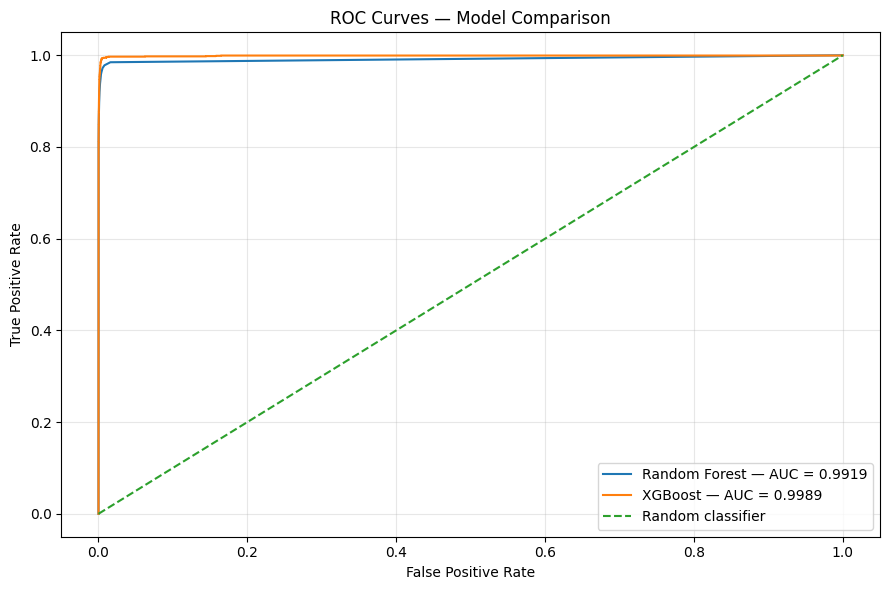

In [24]:
import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_curve,
    roc_auc_score
)

# Random Forest
fpr_rf, tpr_rf, _ = roc_curve(
    y_test,
    y_test_prob_rf
)

roc_auc_rf = roc_auc_score(
    y_test,
    y_test_prob_rf
)

# XGBoost
fpr_xgb, tpr_xgb, _ = roc_curve(
    y_test,
    y_test_prob_xgb
)

roc_auc_xgb = roc_auc_score(
    y_test,
    y_test_prob_xgb
)

# Plot
plt.figure(figsize=(9, 6))

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Random Forest — AUC = {roc_auc_rf:.4f}"
)

plt.plot(
    fpr_xgb,
    tpr_xgb,
    label=f"XGBoost — AUC = {roc_auc_xgb:.4f}"
)

# Random classifier baseline
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — Model Comparison")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

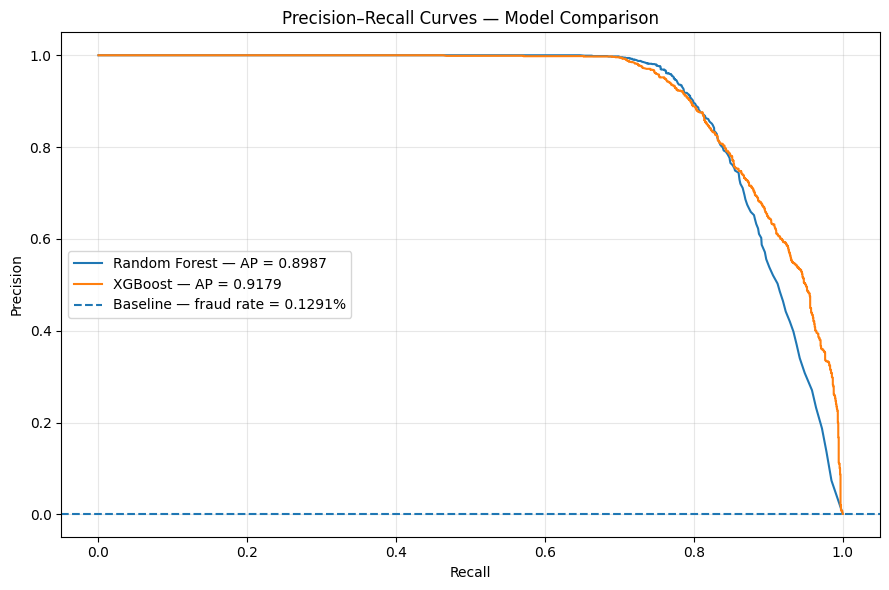

In [25]:
from sklearn.metrics import (
    precision_recall_curve,
    average_precision_score
)

# Random Forest
precision_rf, recall_rf, _ = precision_recall_curve(
    y_test,
    y_test_prob_rf
)

ap_rf = average_precision_score(
    y_test,
    y_test_prob_rf
)

# XGBoost
precision_xgb, recall_xgb, _ = precision_recall_curve(
    y_test,
    y_test_prob_xgb
)

ap_xgb = average_precision_score(
    y_test,
    y_test_prob_xgb
)

# Baseline = Fraud rate in the test set
fraud_prevalence = y_test.mean()

# Plot
plt.figure(figsize=(9, 6))


plt.plot(
    recall_rf,
    precision_rf,
    label=f"Random Forest — AP = {ap_rf:.4f}"
)

plt.plot(
    recall_xgb,
    precision_xgb,
    label=f"XGBoost — AP = {ap_xgb:.4f}"
)

plt.axhline(
    y=fraud_prevalence,
    linestyle="--",
    label=f"Baseline — fraud rate = {fraud_prevalence:.4%}"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curves — Model Comparison")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [26]:
feature_names = preprocessing.get_feature_names_out()

feature_names


array(['num__amount', 'num__oldbalanceOrg', 'num__newbalanceOrig',
       'num__oldbalanceDest', 'num__newbalanceDest', 'cat__type_CASH_IN',
       'cat__type_CASH_OUT', 'cat__type_DEBIT', 'cat__type_PAYMENT',
       'cat__type_TRANSFER'], dtype=object)

In [27]:
clean_feature_names = [
    name.replace("num__", "").replace("cat__", "")
    for name in feature_names
]

In [28]:
rf_importance = pd.DataFrame({
    "feature": clean_feature_names,
    "importance": best_rf.feature_importances_
})

rf_importance = rf_importance.sort_values(
    by="importance",
    ascending=False
)

rf_importance

,feature,importance
4,newbalanceDest,0.340900
1,oldbalanceOrg,0.283426
0,amount,0.179036
3,oldbalanceDest,0.091123
9,type_TRANSFER,0.043042
2,newbalanceOrig,0.030108
6,type_CASH_OUT,0.028423
5,type_CASH_IN,0.002403
8,type_PAYMENT,0.001388
7,type_DEBIT,0.000149


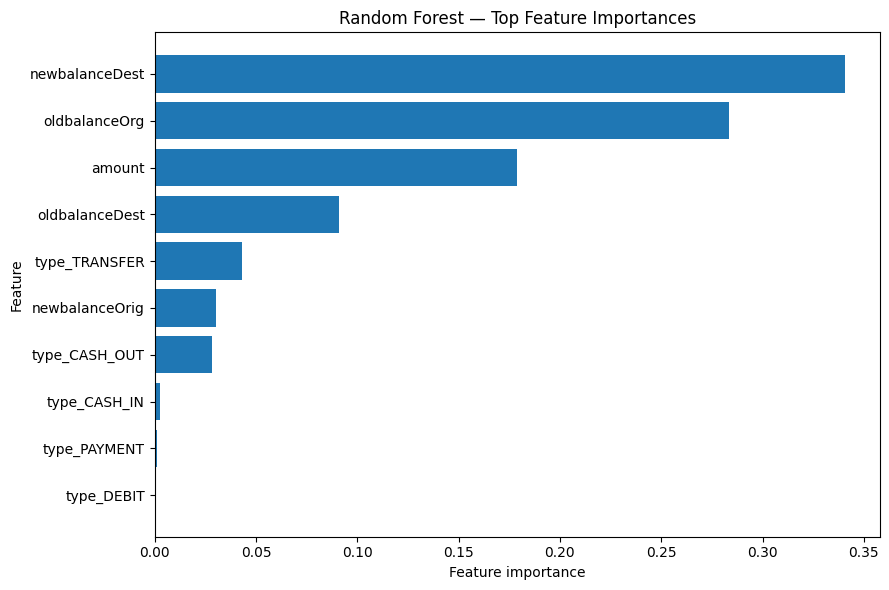

In [29]:
top_rf_features = rf_importance.head(15).sort_values(
    by="importance",
    ascending=True
)

plt.figure(figsize=(9, 6))

plt.barh(
    top_rf_features["feature"],
    top_rf_features["importance"]
)

plt.xlabel("Feature importance")
plt.ylabel("Feature")
plt.title("Random Forest — Top Feature Importances")
plt.tight_layout()
plt.show()

In [30]:
xgb_importance = pd.DataFrame({
    "feature": clean_feature_names,
    "importance": best_xgb.feature_importances_
})

xgb_importance = xgb_importance.sort_values(
    by="importance",
    ascending=False
)

xgb_importance

,feature,importance
4,newbalanceDest,0.690362
1,oldbalanceOrg,0.102025
9,type_TRANSFER,0.093774
6,type_CASH_OUT,0.073329
2,newbalanceOrig,0.021769
0,amount,0.009860
3,oldbalanceDest,0.004853
5,type_CASH_IN,0.002977
8,type_PAYMENT,0.001051
7,type_DEBIT,0.000000


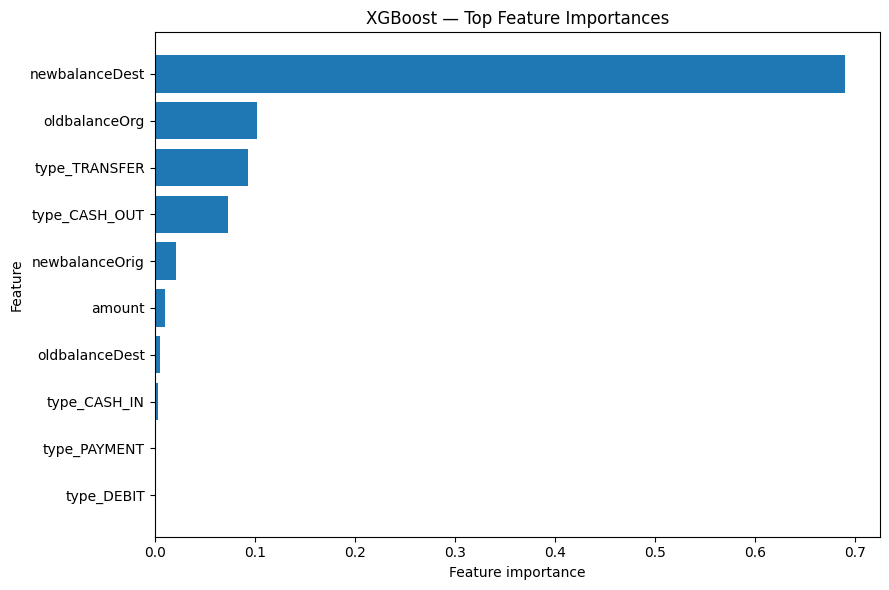

In [31]:
top_xgb_features = xgb_importance.head(15).sort_values(
    by="importance",
    ascending=True
)

plt.figure(figsize=(9, 6))

plt.barh(
    top_xgb_features["feature"],
    top_xgb_features["importance"]
)

plt.xlabel("Feature importance")
plt.ylabel("Feature")
plt.title("XGBoost — Top Feature Importances")
plt.tight_layout()
plt.show()

## Insight - 
It is interesting to see those feature importances. In this dataset, `newbalanceDest` seems to be the strongest predictor of fraud. If we think about it, it is not that surprising : Information about account's balance can be more important than just the amount of money involved in the transaction. 

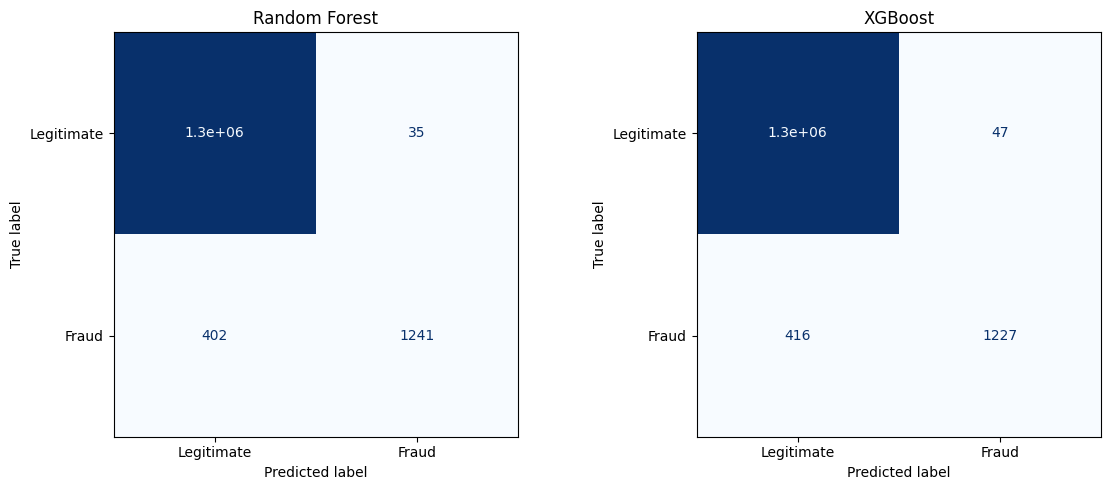

In [33]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Random Forest
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred_rf,
    display_labels=["Legitimate", "Fraud"],
    cmap="Blues",
    colorbar=False,
    ax=axes[0]
)
axes[0].set_title("Random Forest")

# XGBoost
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred_xgb,
    display_labels=["Legitimate", "Fraud"],
    cmap="Blues",
    colorbar=False,
    ax=axes[1]
)
axes[1].set_title("XGBoost")

plt.tight_layout()
plt.show()

## 5. Conclusion

Based on it's high ROC-AUC score and average precision, i think XGBoost is the best final model to pick (respectively, AUC = 0,9919 vs 0,9989 and AP = 0.899 vs 0.918). The random forest is a very good one too.

Our final metrics for our model (XGBoost) shows : 
Precision = 96%

Recall = 75%

PR AUC = 0.918

Which means that when the model raises a fraud alert, it is almost always correct (precision). However, roughly one out of every four fraudulent transactions is still missed (recall).


Now, no model can be perfect and further decisions should be made from a business perspective. 
What does cost more : (1) Missing fraud or (2) investigating false alerts ? 
- If (1), then it is still possible to try maximize precision with a recall fixed about what is needed. 95% recalls means almost 95% fraudulent transactions are detected, for example. But of course, precision will be lower than what we already have. It will mean more tuning, maybe some feature engineering, and more optimization, as well as probably modifying the classification threshold from 0.5 to whatever is needed from a business point of view. 
- If (2), and if the system is satisfactory enough from a business perspective (let's say it wins investigators a lot of time or it make less mistakes than them to correctly identify a fraud) then we can finally save our model and maybe design a system for it to run on. 

In [41]:
import joblib

final_model = best_xgb
joblib.dump(final_model, "../models/final_model_fraud_detection_xgb.pkl")
joblib.dump(best_rf, "../models/fraud_detection_rf_model.pkl")

['../models/fraud_detection_rf_model.pkl']